In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import neural_utils as nu
from mpl_toolkits import mplot3d
import math

test


In [2]:
# setup data 

# Domain : [0,1]^2 x [0,1]
# IC: u(x, y, 0) = sin(pi x)sin(pi y)
# BC: Dirichlet B(x,y, t) = 0 on boundary

# generate data

# can parametrize boundary with 2d rectangle

N_boundary = 200

def boundary_map(s):
    """
    s: shape (N, 1), values in [0, 1]
    returns x, y on boundary of [0,1]^2
    """
    s = s.view(-1, 1)
    q = 4 * s  # now q in [0, 4]

    x = torch.empty_like(q)
    y = torch.empty_like(q)

    m1 = (q >= 0) & (q < 1)
    m2 = (q >= 1) & (q < 2)
    m3 = (q >= 2) & (q < 3)
    m4 = (q >= 3) & (q <= 4)

    # left edge: x=0, y=q
    x[m1] = 0
    y[m1] = q[m1]

    # top edge: x=q-1, y=1
    x[m2] = q[m2] - 1
    y[m2] = 1

    # right edge: x=1, y=3-q
    x[m3] = 1
    y[m3] = 3 - q[m3]

    # bottom edge: x=4-q, y=0
    x[m4] = 4 - q[m4]
    y[m4] = 0

    return x, y

z = torch.rand(N_boundary,2)
s = z[:, 0:1]      
t = z[:, 1:2]  

x, y = boundary_map(s)

X_b = torch.cat([x, y, t], dim=1)
U_b = torch.zeros_like(x)

N_initial = 200

def initial(X):
    return torch.sin(torch.pi * X[:,0:1])*torch.sin(torch.pi * X[:,1:2])

x_init = torch.rand(N_initial, 2)
t = torch.zeros(N_initial,1)
X_init = torch.cat([x_init,t], dim = 1)
U_init = initial(X_init)

In [ ]:
# Sample collocation points
N_col = 1000
X_col = nu.sample(dim=3, N=N_col, domain_map=nu.identity_map, device='cpu')

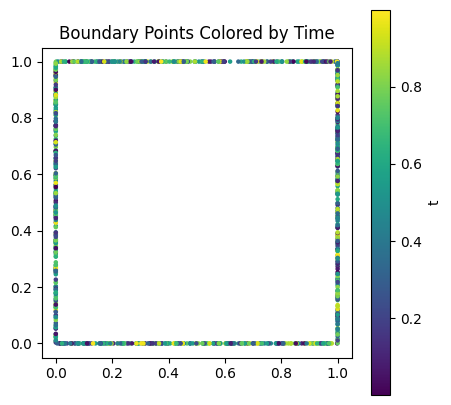

In [4]:
x = X_b[:, 0].detach().numpy()
y = X_b[:, 1].detach().numpy()
t = X_b[:, 2].detach().numpy()

plt.figure(figsize=(5,5))
plt.scatter(x, y, c=t, s=5, cmap='viridis')
plt.colorbar(label="t")
plt.gca().set_aspect('equal')
plt.title("Boundary Points Colored by Time")
plt.show()

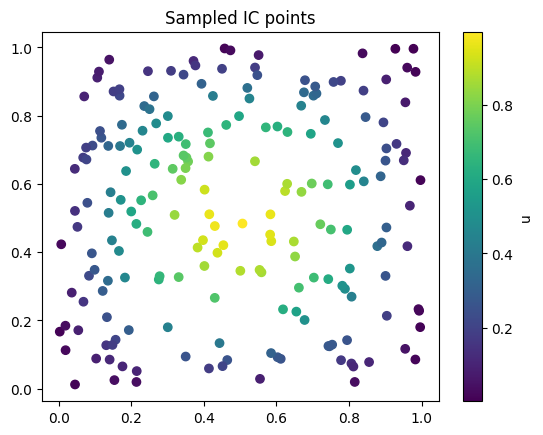

In [3]:
plt.scatter(x_init[:,0], x_init[:,1], c=U_init.squeeze(), cmap='viridis')
plt.colorbar(label="u")
plt.title("Sampled IC points")
plt.show()

In [4]:
model = nu.FCN(3,1,20,5)

model



FCN(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=20, bias=True)
    (1): Tanh()
    (2): Linear(in_features=20, out_features=20, bias=True)
    (3): Tanh()
    (4): Linear(in_features=20, out_features=20, bias=True)
    (5): Tanh()
    (6): Linear(in_features=20, out_features=20, bias=True)
    (7): Tanh()
    (8): Linear(in_features=20, out_features=20, bias=True)
    (9): Tanh()
    (10): Linear(in_features=20, out_features=1, bias=True)
  )
)

In [5]:
def make_heat_2d_residual(alpha):

    def residual_fn(X, u, grad_u):
        u_x = grad_u[:, 0:1]
        u_y = grad_u[:, 1:2]
        u_t = grad_u[:, 2:3]

        grad_u_x = nu.gradients(u_x, X)
        grad_u_y = nu.gradients(u_y, X)

        u_xx = grad_u_x[:, 0:1]
        u_yy = grad_u_y[:, 1:2]

        return u_t - alpha * (u_xx + u_yy)

    return residual_fn

residual_fn = make_heat_2d_residual(0.1)

def analytic(alpha, x,y, t):
    return torch.exp(-2 * alpha * math.pi**2 * t) * torch.sin(math.pi * x) * torch.sin(math.pi * y)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
X_data = torch.cat([X_b,X_init], dim = 0)
U_data = torch.cat([U_b, U_init], dim=0)

losses, losses_data, losses_phys, _, _, best_state, best_avg_loss = nu.train(50000, optimizer, X_data, U_data, model, residual_fn, 1, X_col)

model.load_state_dict(best_state)
print("best 100 epoch avg loss:", best_avg_loss)

0 0.12056290358304977 0.12054365873336792 1.9242657799622975e-05
100 0.07909359782934189 0.07904844731092453 4.515371983870864e-05
200 0.07671692967414856 0.07544363290071487 0.0012732952600345016
300 0.07662069797515869 0.07507681101560593 0.0015438852133229375
400 0.0765327587723732 0.07495937496423721 0.0015733801992610097
500 0.07643692195415497 0.07483633607625961 0.00160058808978647
600 0.07632599771022797 0.07470028102397919 0.001625714940018952
700 0.07618928700685501 0.07454034686088562 0.0016489379340782762
800 0.07600940763950348 0.07433955371379852 0.0016698535764589906
900 0.07575355470180511 0.07406676560640335 0.0016867880476638675
1000 0.075348399579525 0.07365331798791885 0.0016950807766988873
1100 0.07459726929664612 0.07291343063116074 0.001683837384916842
1200 0.07290379703044891 0.07125192880630493 0.0016518669435754418
1300 0.06868433952331543 0.06691901385784149 0.0017653220565989614
1400 0.05958499759435654 0.05735792592167854 0.0022270726040005684
1500 0.046908

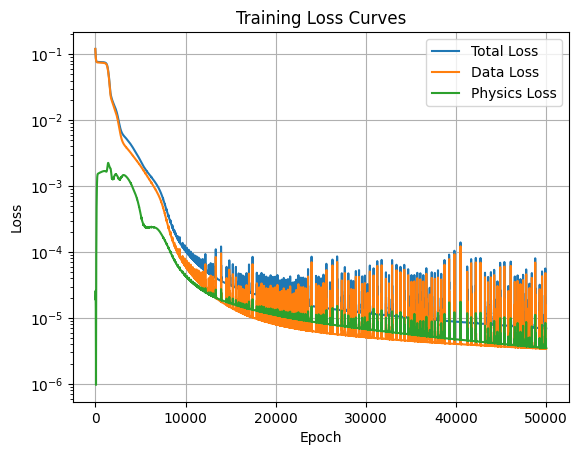

In [7]:
epochs = range(len(losses))

plt.plot(epochs, losses, label='Total Loss')
plt.plot(epochs, losses_data, label='Data Loss')
plt.plot(epochs, losses_phys, label='Physics Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'Training Loss Curves')

plt.yscale('log')
plt.legend()
plt.grid()

plt.show()

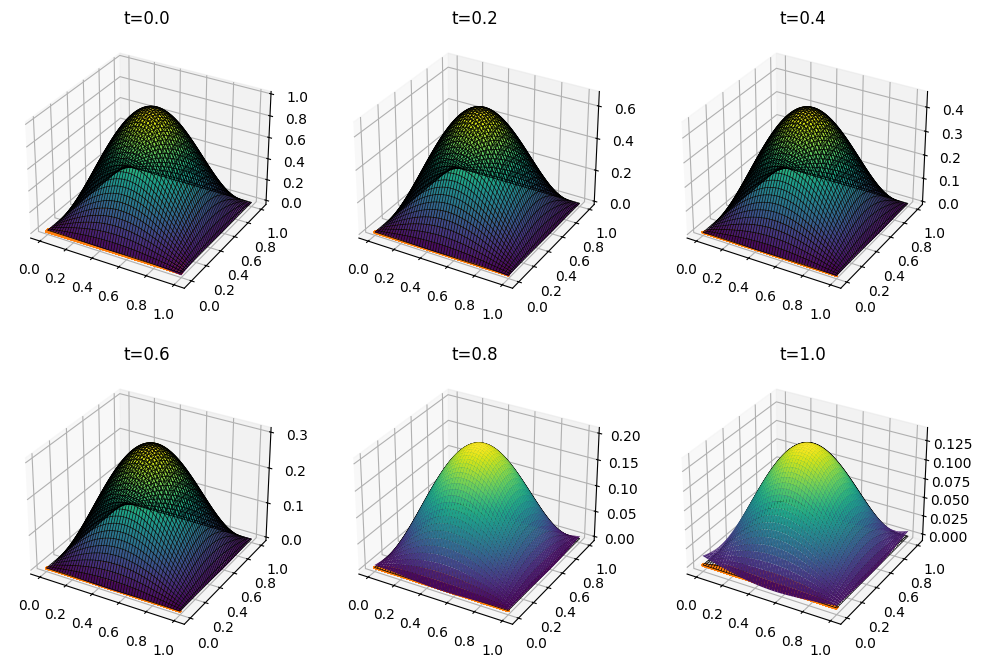

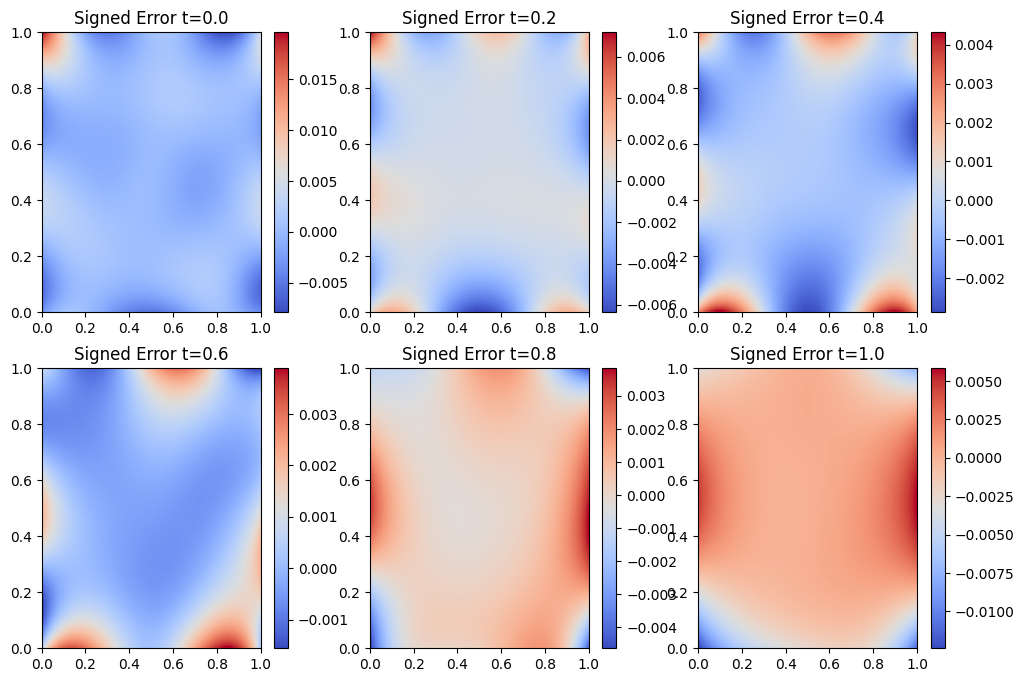

In [8]:
# time slice visualization

N_grid = 100
x = torch.linspace(0,1, N_grid)
y = torch.linspace(0,1, N_grid)


times = [0, 0.2, 0.4, 0.6, 0.8,1]

fig1, axes1 = plt.subplots(2,3, figsize=(12,8), subplot_kw={"projection": "3d"})
axes1 = axes1.flatten()

fig2, axes2 = plt.subplots(2,3, figsize=(12,8))
axes2 = axes2.flatten()

for i,t in enumerate(times):
    X,Y= torch.meshgrid(x,y, indexing="ij")

    T = torch.full_like(X, t)

    XYT = torch.stack([X.reshape(-1),Y.reshape(-1),T.reshape(-1)], dim=1)

    with torch.no_grad():
        u_pred = model(XYT).reshape(N_grid,N_grid).detach().cpu().numpy()

    u_true = analytic(0.1, X,Y,T).detach().cpu().numpy()

    ax1 = axes1[i]

    ax1.plot_surface(X, Y, u_pred, cmap="viridis")
    ax1.plot_wireframe(X, Y, u_true,
    color='black',
    linewidth=0.5)

    ax1.plot(x, u_true, '--', label='true')
    ax1.plot(x, u_pred, '-', label='pred')

    ax1.set_title(f"t={t:.1f}")
    ax1.grid()

    ax2 = axes2[i]

    plot = ax2.imshow(u_true - u_pred, 
    cmap="coolwarm",
    extent=[0,1,-0,1],
    origin='lower',
    aspect='auto',
    )

    ax2.set_title(f"Signed Error t={t:.1f}")
    fig2.colorbar(plot, ax=ax2)





In [10]:
# loss landscape visualization

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)



1781
